<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [2]:
from google.colab import files
uploaded = files.upload()


Saving Alcohol_Sales.csv to Alcohol_Sales.csv


In [3]:
df = pd.read_csv('Alcohol_Sales.csv')

print(df.head())

     Month   Sales
0  2015-01  209.93
1  2015-02  215.33
2  2015-03  247.60
3  2015-04  278.71
4  2015-05  253.11


In [4]:
data = df.iloc[:,1:2].values

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [6]:
def create_dataset(dataset, time_step=1):

    X, Y = [], []

    for i in range(len(dataset)-time_step-1):

        a = dataset[i:(i+time_step), 0]

        X.append(a)
        Y.append(dataset[i + time_step, 0])

    return np.array(X), np.array(Y)


In [7]:
time_step = 12

X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM
X = X.reshape(X.shape[0], X.shape[1], 1)


In [8]:
model = Sequential()

model.add(LSTM(50, return_sequences=True,
               input_shape=(time_step,1)))

model.add(LSTM(50))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    loss='mean_squared_error',
    optimizer='adam'
)

In [10]:
history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=16
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.1664
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0323 
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0256 
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0211 
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0186
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0176
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0172
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0170 
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0170 
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0168
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166
Epoch 13/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0162 
Epoch 14/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0160 
Epoch 15/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0158 
Epoch 16/50
7/7 ━━━━━━━━━━━━━━━━━━━

In [11]:
predictions = model.predict(X)

predictions = scaler.inverse_transform(predictions)

original_data = scaler.inverse_transform(scaled_data)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step


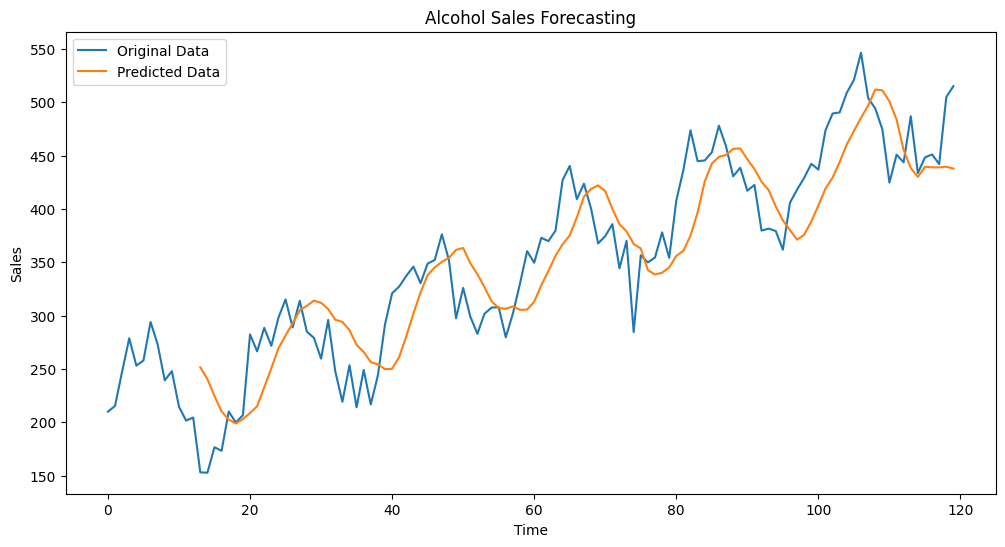

In [12]:
plt.figure(figsize=(12,6))

plt.plot(original_data, label='Original Data')

plt.plot(
    range(time_step+1, time_step+1+len(predictions)),
    predictions,
    label='Predicted Data'
)

plt.title("Alcohol Sales Forecasting")
plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()
